

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>


<div class="alert alert-danger">
<strong>Comentário do revisor v1</strong>

Estamos no caminho certo com essa versão, mas retocar os pontos indicados abaixo nos fará chegar em um resultado ainda mais incrível.
    
Conte comigo para ajudá-lo (a) em qualquer questão que possa vir a ter! Lembre-se de usar as caixas azuis para se comunicar comigo.
    
Até breve.
</div>


Como relatar uma história usando dados

Projeto para uma cafeteria com garçons robôs em Los Angeles.

1- Limpeza de dados

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/datasets/rest_data_us_upd.csv')

In [3]:
print(df)

         id          object_name                      address  chain  \
0     11786  HABITAT COFFEE SHOP       3708 N EAGLE ROCK BLVD  False   
1     11787             REILLY'S            100 WORLD WAY 120  False   
2     11788       STREET CHURROS      6801 HOLLYWOOD BLVD 253  False   
3     11789    TRINITI ECHO PARK           1814 W SUNSET BLVD  False   
4     11790               POLLEN           2100 ECHO PARK AVE  False   
...     ...                  ...                          ...    ...   
9646  21432      HALL OF JUSTICE             217 W TEMPLE AVE  False   
9647  21433          FIN-MELROSE             5750 MELROSE AVE  False   
9648  21434          JUICY WINGZ          6741 HOLLYWOOD BLVD   True   
9649  21435      MEDIDATE COFFEE      548 S SPRING ST STE 100  False   
9650  21436         CAFE SPROUTS  1300 S SAN PEDRO ST STE 111   True   

     object_type  number  
0           Cafe      26  
1     Restaurant       9  
2      Fast Food      20  
3     Restaurant      22  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 452.5+ KB
None


In [5]:
print(f"Valores ausentes:\n{df.isnull().sum()}")

Valores ausentes:
id             0
object_name    0
address        0
chain          3
object_type    0
number         0
dtype: int64


In [6]:
print(f"Duplicados: {df.duplicated().sum()}")

Duplicados: 0


In [7]:
df['chain'] = df['chain'].astype(bool)
df['number'] = pd.to_numeric(df['number'], errors='coerce')

In [8]:
df = df.dropna()

In [9]:
df = df.drop_duplicates()

In [10]:
print("\nDados após limpeza:")
print(df.info())
print(f"Valores ausentes:\n{df.isnull().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")


Dados após limpeza:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9651 non-null   bool  
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: bool(1), int64(2), object(3)
memory usage: 461.8+ KB
None
Valores ausentes:
id             0
object_name    0
address        0
chain          0
object_type    0
number         0
dtype: int64
Duplicados: 0


2- As proporções de vários tipos de estabelecimentos

In [11]:
contagem_tipos = df['object_type'].value_counts()
print(contagem_tipos)

Restaurant    7255
Fast Food     1066
Cafe           435
Pizza          320
Bar            292
Bakery         283
Name: object_type, dtype: int64


In [12]:
proporcoes = df['object_type'].value_counts(normalize=True) * 100
print(proporcoes)

Restaurant    75.173557
Fast Food     11.045488
Cafe           4.507305
Pizza          3.315719
Bar            3.025593
Bakery         2.932339
Name: object_type, dtype: float64


<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>


In [13]:
import matplotlib.pyplot as plt

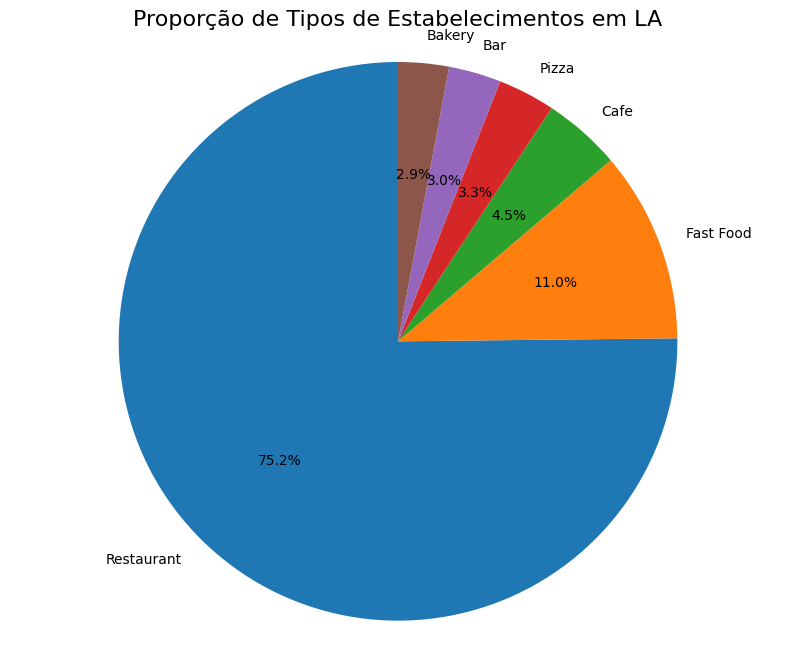

In [14]:
plt.figure(figsize=(10, 8))
plt.pie(contagem_tipos.values, 
         labels=contagem_tipos.index, 
         autopct='%1.1f%%',  
         startangle=90)      

plt.title('Proporção de Tipos de Estabelecimentos em LA', fontsize=16)
plt.axis('equal')  
plt.show()

A rede de restaurantes apresenta maior representatividade, seguida pelas redes de fast food e cafés.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Tipos de estabelecimento foram investigados com presença adequada de visualização e conclusão!
</div>

As proporções de estabelecimentos de rede e não:

In [15]:
contagem_chain = df['chain'].value_counts()
print("Contagem de estabelecimentos:")
print(contagem_chain)

Contagem de estabelecimentos:
False    5972
True     3679
Name: chain, dtype: int64


In [16]:
proporcoes_chain = df['chain'].value_counts(normalize=True) * 100
print("\nProporções em percentual:")
print(proporcoes_chain)


Proporções em percentual:
False    61.879598
True     38.120402
Name: chain, dtype: float64


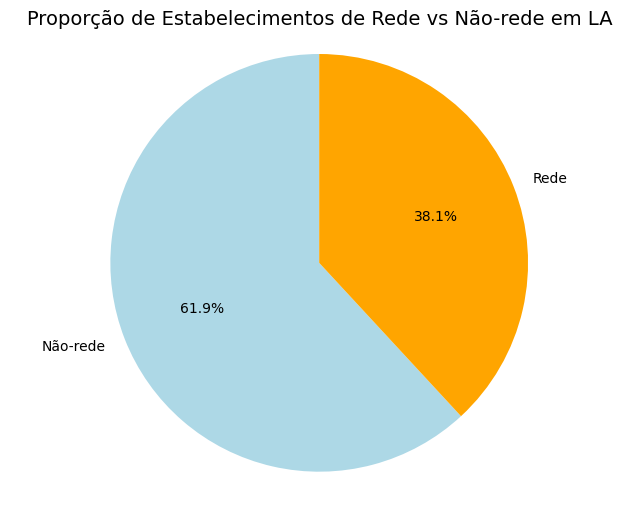

In [17]:
import seaborn as sns

plt.figure(figsize=(8, 6))
labels = ['Não-rede', 'Rede'] if False in contagem_chain.index else ['Rede', 'Não-rede']
plt.pie(contagem_chain.values, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=['lightblue', 'orange'])
plt.title('Proporção de Estabelecimentos de Rede vs Não-rede em LA', fontsize=14)
plt.axis('equal')
plt.show()

As redes de restaurantes independentes apresentam maior dimensão em comparação com as redes dependentes.

Tipo de estabelecimento é típico para redes:

In [18]:
estabelecimentos_rede = df[df['chain'] == True]
print(f"Total de estabelecimentos de rede: {len(estabelecimentos_rede)}")

Total de estabelecimentos de rede: 3679


In [19]:
tipos_rede = estabelecimentos_rede['object_type'].value_counts()
print("Tipos de estabelecimentos entre as redes:")
print(tipos_rede)

Tipos de estabelecimentos entre as redes:
Restaurant    2294
Fast Food      605
Bakery         283
Cafe           266
Pizza          154
Bar             77
Name: object_type, dtype: int64


In [20]:
proporcoes_tipos_rede = estabelecimentos_rede['object_type'].value_counts(normalize=True) * 100
print("\nProporções entre estabelecimentos de rede:")
print(proporcoes_tipos_rede)


Proporções entre estabelecimentos de rede:
Restaurant    62.353901
Fast Food     16.444686
Bakery         7.692308
Cafe           7.230226
Pizza          4.185920
Bar            2.092960
Name: object_type, dtype: float64


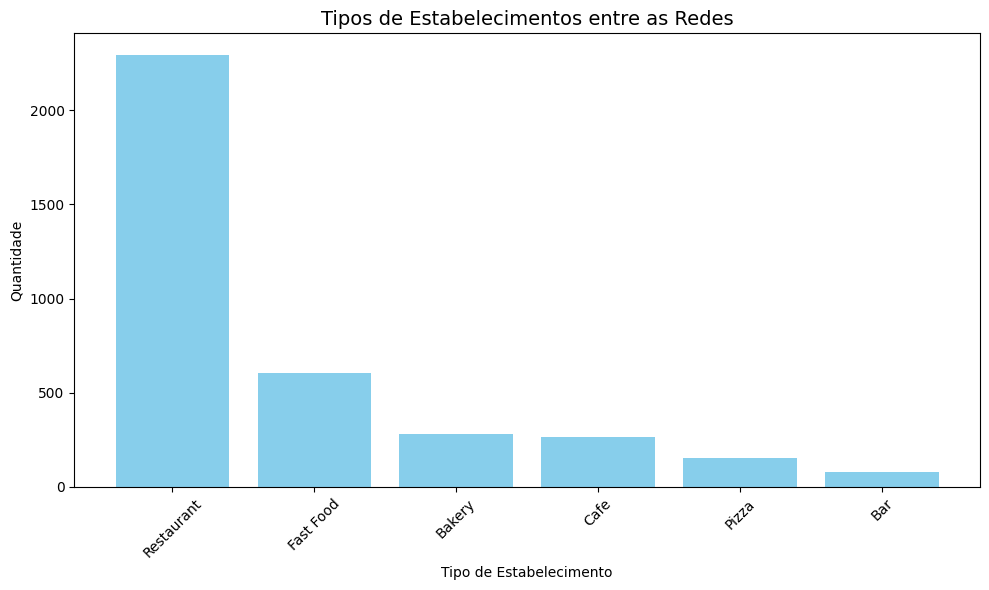

In [21]:
plt.figure(figsize=(10, 6))
plt.bar(tipos_rede.index, tipos_rede.values, color='skyblue')
plt.title('Tipos de Estabelecimentos entre as Redes', fontsize=14)
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As redes de restaurantes continuam predominando no mercado, seguidas pelas redes de fast food e, por fim, pelas padarias.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Redes investigadas tanto no agregado quanto na quebra por tipo de estabelecimento.
</div>


O que caracteriza redes: muitos estabelecimentos com um pequeno número de assentos ou poucos estabelecimentos com muitos assentos?:

In [22]:
print("=== ESTABELECIMENTOS DE REDE ===")
print(estabelecimentos_rede['number'].describe())

print("\n=== ESTABELECIMENTOS NÃO-REDE ===")
estabelecimentos_nao_rede = df[df['chain'] == False]
print(estabelecimentos_nao_rede['number'].describe())

=== ESTABELECIMENTOS DE REDE ===
count    3679.000000
mean       39.675455
std        43.426312
min         1.000000
25%        13.000000
50%        25.000000
75%        44.000000
max       229.000000
Name: number, dtype: float64

=== ESTABELECIMENTOS NÃO-REDE ===
count    5972.000000
mean       46.171467
std        49.875746
min         1.000000
25%        14.000000
50%        28.000000
75%        47.000000
max       229.000000
Name: number, dtype: float64


In [23]:
media_rede = estabelecimentos_rede['number'].mean()
media_nao_rede = estabelecimentos_nao_rede['number'].mean()

print(f"Média de assentos - REDES: {media_rede:.1f}")
print(f"Média de assentos - NÃO-REDES: {media_nao_rede:.1f}")
print(f"Diferença: {abs(media_rede - media_nao_rede):.1f} assentos")

Média de assentos - REDES: 39.7
Média de assentos - NÃO-REDES: 46.2
Diferença: 6.5 assentos


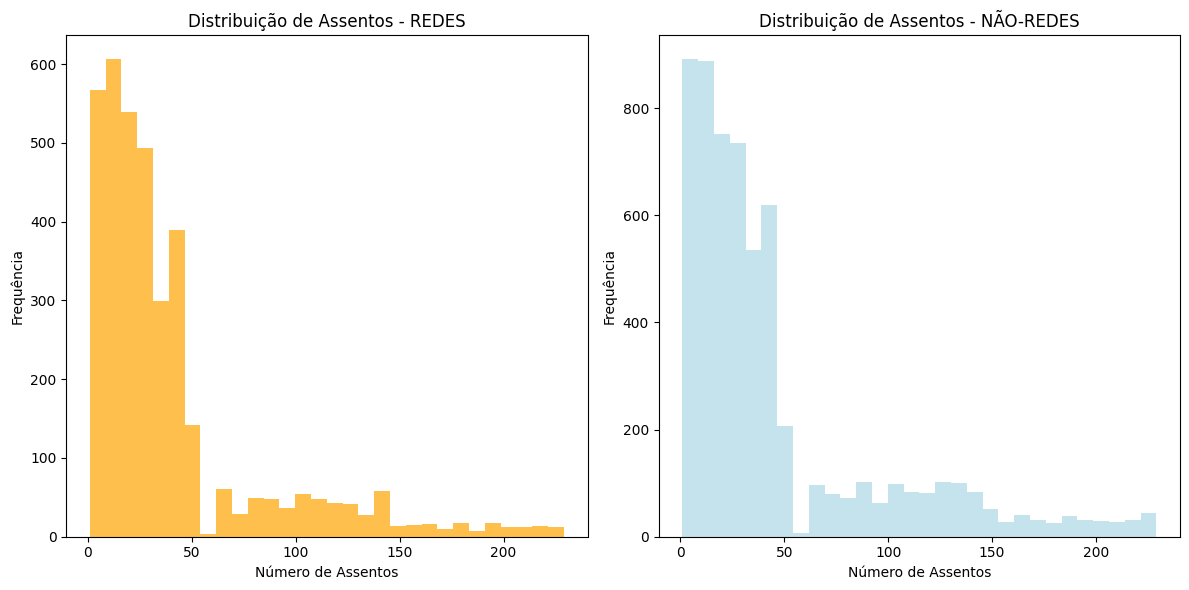

In [24]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(estabelecimentos_rede['number'], bins=30, alpha=0.7, color='orange', label='Redes')
plt.title('Distribuição de Assentos - REDES')
plt.xlabel('Número de Assentos')
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
plt.hist(estabelecimentos_nao_rede['number'], bins=30, alpha=0.7, color='lightblue', label='Não-redes')
plt.title('Distribuição de Assentos - NÃO-REDES')
plt.xlabel('Número de Assentos')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

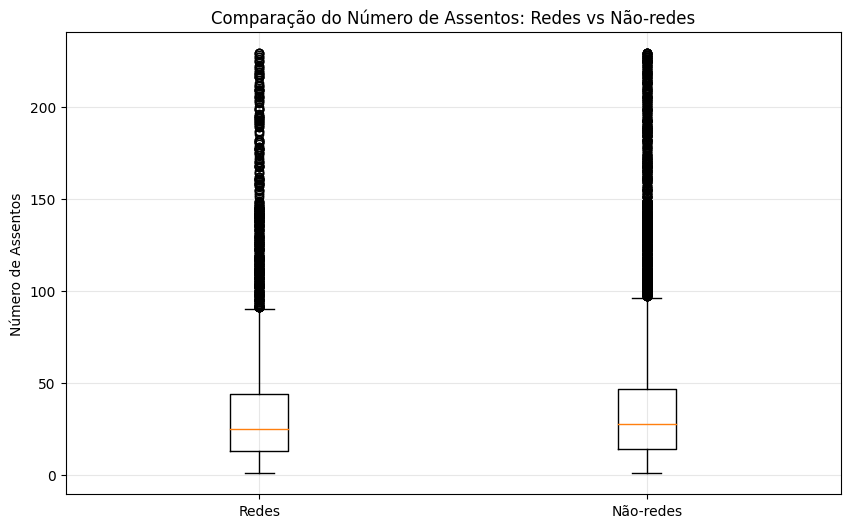

In [25]:
plt.figure(figsize=(10, 6))
data_para_boxplot = [estabelecimentos_rede['number'], estabelecimentos_nao_rede['number']]
labels = ['Redes', 'Não-redes']

plt.boxplot(data_para_boxplot, labels=labels)
plt.title('Comparação do Número de Assentos: Redes vs Não-redes')
plt.ylabel('Número de Assentos')
plt.grid(True, alpha=0.3)
plt.show()

As redes adotam uma estratégia de expansão com muitos estabelecimentos pequenos, focando em alcance, padronização e conveniência, enquanto os independentes operam com menos unidades e maior capacidade, priorizando experiência, qualidade e maior rentabilidade por local.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Comparativo da volumetria de assentos entre redes e não redes foi realizada de forma elucidativa.
</div>

O número médio de assentos para cada tipo de restaurante:

In [26]:
media_assentos_por_tipo = df.groupby('object_type')['number'].mean()
print("Número médio de assentos por tipo de restaurante:")
print(media_assentos_por_tipo.sort_values(ascending=False))

Número médio de assentos por tipo de restaurante:
object_type
Restaurant    48.042316
Bar           44.767123
Fast Food     31.837711
Pizza         28.459375
Cafe          25.000000
Bakery        21.773852
Name: number, dtype: float64


In [27]:
tipo_maior_media = media_assentos_por_tipo.idxmax()
maior_media = media_assentos_por_tipo.max()
print(f"\nTipo com maior número médio de assentos: {tipo_maior_media}")
print(f"Média de assentos: {maior_media:.1f}")


Tipo com maior número médio de assentos: Restaurant
Média de assentos: 48.0


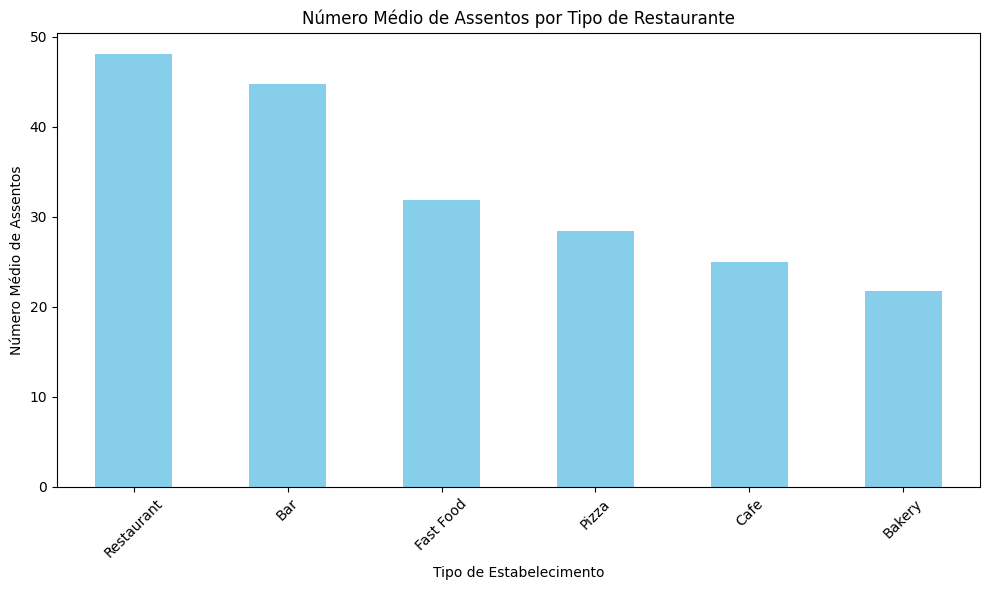

In [28]:
plt.figure(figsize=(10, 6))
media_assentos_por_tipo.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Número Médio de Assentos por Tipo de Restaurante')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Número Médio de Assentos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

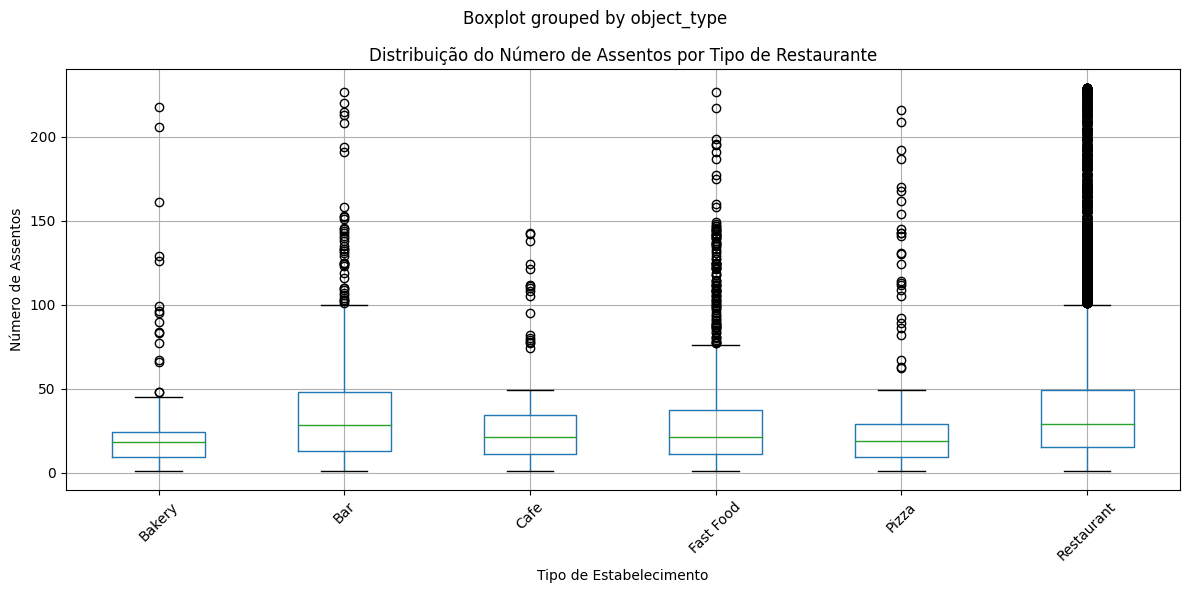

In [29]:
plt.figure(figsize=(12, 6))
df.boxplot(column='number', by='object_type', figsize=(12, 6))
plt.title('Distribuição do Número de Assentos por Tipo de Restaurante')
plt.xlabel('Tipo de Estabelecimento')
plt.ylabel('Número de Assentos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Os dados mostram que restaurantes e bares possuem maior número médio de assentos, pois oferecem experiências mais longas e voltadas para grupos, enquanto fast foods priorizam menor capacidade para aumentar a rotatividade. Cafés e padarias apresentam os menores valores, refletindo um modelo mais rápido e com menor permanência dos clientes.

Esses resultados sugerem que o tipo de estabelecimento influencia diretamente sua capacidade e estratégia, sendo um fator importante para decisões de negócio, como no caso de uma cafeteria com garçons robôs, que deve equilibrar eficiência, experiência do cliente e capacidade de atendimento.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Média de assentos caclulada e análisada por meio de visualizações adequadas.

</div>

Os dados dos nomes das ruas da coluna address:

In [30]:
print("Exemplos de endereços:")
print(df['address'].head(10))

Exemplos de endereços:
0             3708 N EAGLE ROCK BLVD
1                  100 WORLD WAY 120
2            6801 HOLLYWOOD BLVD 253
3                 1814 W SUNSET BLVD
4                 2100 ECHO PARK AVE
5                10004 NATIONAL BLVD
6                  100 WORLD WAY 126
7              3500 W 6TH ST STE 226
8    3027 N SAN FERNANDO RD UNIT 103
9               3707 N CAHUENGA BLVD
Name: address, dtype: object


In [31]:
df['street_name'] = df['address'].str.replace(r'^\d+\s*', '', regex=True)
print("Primeiros 10 nomes de ruas extraídos:")
print(df['street_name'].head(10))

Primeiros 10 nomes de ruas extraídos:
0             N EAGLE ROCK BLVD
1                 WORLD WAY 120
2            HOLLYWOOD BLVD 253
3                 W SUNSET BLVD
4                 ECHO PARK AVE
5                 NATIONAL BLVD
6                 WORLD WAY 126
7              W 6TH ST STE 226
8    N SAN FERNANDO RD UNIT 103
9               N CAHUENGA BLVD
Name: street_name, dtype: object


In [32]:
df['street_name'] = df['address'].str.extract(r'^\d+\s+(.+?)(?:\s+\d+)?$')[0]
print("Primeiros 10 nomes de ruas extraídos:")
print(df['street_name'].head(10))

Primeiros 10 nomes de ruas extraídos:
0         N EAGLE ROCK BLVD
1                 WORLD WAY
2            HOLLYWOOD BLVD
3             W SUNSET BLVD
4             ECHO PARK AVE
5             NATIONAL BLVD
6                 WORLD WAY
7              W 6TH ST STE
8    N SAN FERNANDO RD UNIT
9           N CAHUENGA BLVD
Name: street_name, dtype: object


In [33]:
df['street_name'] = df['street_name'].str.strip()
df['street_name'] = df['street_name'].str.upper()  # Padronizar em maiúsculas

print("Verificação dos nomes das ruas:")
print(df[['address', 'street_name']].head(10))

Verificação dos nomes das ruas:
                           address             street_name
0           3708 N EAGLE ROCK BLVD       N EAGLE ROCK BLVD
1                100 WORLD WAY 120               WORLD WAY
2          6801 HOLLYWOOD BLVD 253          HOLLYWOOD BLVD
3               1814 W SUNSET BLVD           W SUNSET BLVD
4               2100 ECHO PARK AVE           ECHO PARK AVE
5              10004 NATIONAL BLVD           NATIONAL BLVD
6                100 WORLD WAY 126               WORLD WAY
7            3500 W 6TH ST STE 226            W 6TH ST STE
8  3027 N SAN FERNANDO RD UNIT 103  N SAN FERNANDO RD UNIT
9             3707 N CAHUENGA BLVD         N CAHUENGA BLVD


In [34]:
print(f"Número total de ruas únicas: {df['street_name'].nunique()}")

print("\nRuas mais comuns:")
print(df['street_name'].value_counts().head(10))

Número total de ruas únicas: 2295

Ruas mais comuns:
W SUNSET BLVD        304
W PICO BLVD          303
WILSHIRE BLVD        205
HOLLYWOOD BLVD       192
SANTA MONICA BLVD    186
S WESTERN AVE        170
W 3RD ST             164
S VERMONT AVE        161
S FIGUEROA ST        157
W OLYMPIC BLVD       150
Name: street_name, dtype: int64


Gráfico de dez ruas com o maior número de restaurantes:

In [35]:
restaurantes_por_rua = df['street_name'].value_counts()
print("Top 10 ruas com mais restaurantes:")
print(restaurantes_por_rua.head(10))

Top 10 ruas com mais restaurantes:
W SUNSET BLVD        304
W PICO BLVD          303
WILSHIRE BLVD        205
HOLLYWOOD BLVD       192
SANTA MONICA BLVD    186
S WESTERN AVE        170
W 3RD ST             164
S VERMONT AVE        161
S FIGUEROA ST        157
W OLYMPIC BLVD       150
Name: street_name, dtype: int64


In [36]:
top_10_ruas = restaurantes_por_rua.head(10)
print(top_10_ruas)

W SUNSET BLVD        304
W PICO BLVD          303
WILSHIRE BLVD        205
HOLLYWOOD BLVD       192
SANTA MONICA BLVD    186
S WESTERN AVE        170
W 3RD ST             164
S VERMONT AVE        161
S FIGUEROA ST        157
W OLYMPIC BLVD       150
Name: street_name, dtype: int64


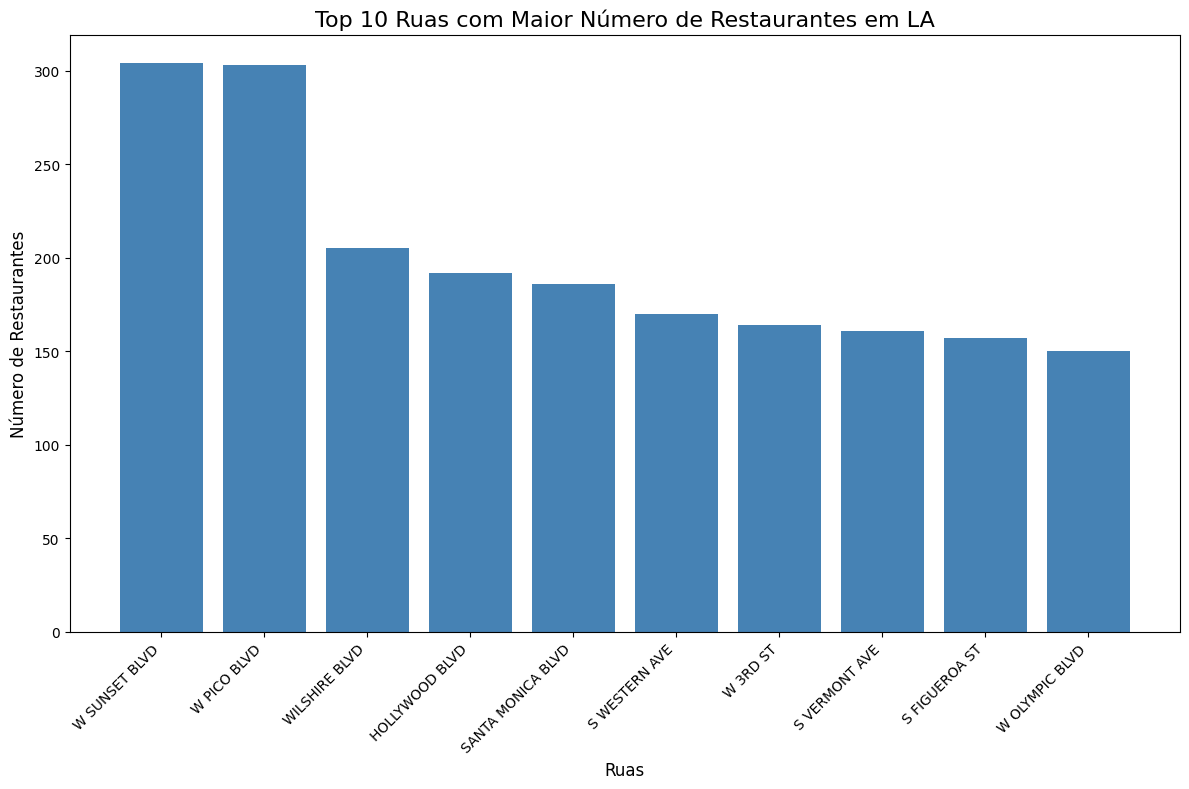

In [37]:
plt.figure(figsize=(12, 8))
plt.bar(range(len(top_10_ruas)), top_10_ruas.values, color='steelblue')
plt.title('Top 10 Ruas com Maior Número de Restaurantes em LA', fontsize=16)
plt.xlabel('Ruas', fontsize=12)
plt.ylabel('Número de Restaurantes', fontsize=12)
plt.xticks(range(len(top_10_ruas)), top_10_ruas.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

Com base nos dados analisados, verifica-se que as ruas com maior concentração de restaurantes são W Sunset Blvd (304), W Pico Blvd (303) e Wilshire Blvd (205), indicando áreas de alta atividade comercial e potencial atratividade para novos estabelecimentos.

Ruas que têm apenas um restaurante:

In [38]:
ruas_com_um_restaurante = restaurantes_por_rua[restaurantes_por_rua == 1]

print("Ruas com apenas 1 restaurante:")
print(f"Total de ruas: {len(ruas_com_um_restaurante)}")

Ruas com apenas 1 restaurante:
Total de ruas: 1707


In [39]:
print("\nExemplos de ruas com apenas 1 restaurante:")
print(ruas_com_um_restaurante.head(10))


Exemplos de ruas com apenas 1 restaurante:
N BROADWAY BLVD STE 101A    1
E 58TH PL                   1
S ALAMEDA ST #703           1
W 4TH ST STE A              1
S FIGUEROA ST STE #419      1
S FIGUEROA ST 35TH          1
WORLD WAY A1-16             1
S JAPANESE VILLAGE PLZ      1
1/2 SHATTO PL               1
S BROADWAY STE #A           1
Name: street_name, dtype: int64


In [40]:
total_ruas = len(restaurantes_por_rua)
ruas_unicas = len(ruas_com_um_restaurante)
percentual = (ruas_unicas / total_ruas) * 100

print(f"\nResumo:")
print(f"Total de ruas únicas: {total_ruas}")
print(f"Ruas com apenas 1 restaurante: {ruas_unicas}")
print(f"Percentual: {percentual:.1f}%")


Resumo:
Total de ruas únicas: 2295
Ruas com apenas 1 restaurante: 1707
Percentual: 74.4%


A análise mostra que 74,4% das ruas (1.707 de 2.295) têm apenas um restaurante, o que indica uma distribuição muito dispersa dos estabelecimentos em Los Angeles.

Para uma cafeteria com robôs, focar em áreas mais centrais realmente faz muito sentido estratégico, por ter maior fluxo de pessoas e por ser uma curiosidade e novidade.

Tendências para as ruas com muitos restaurantes e distribuição de número de assentos

In [41]:
top_10_ruas_nomes = top_10_ruas.index.tolist()

estabelecimentos_top_ruas = df[df['street_name'].isin(top_10_ruas_nomes)]

print(f"Total de estabelecimentos nas top 10 ruas: {len(estabelecimentos_top_ruas)}")

Total de estabelecimentos nas top 10 ruas: 1992


In [42]:
print("=== RUAS COM MUITOS RESTAURANTES ===")
print(estabelecimentos_top_ruas['number'].describe())

print("\n=== MÉDIA GERAL DE LA ===")
print(df['number'].describe())

media_top_ruas = estabelecimentos_top_ruas['number'].mean()
media_geral = df['number'].mean()

print(f"\nComparação de médias:")
print(f"Média nas top 10 ruas: {media_top_ruas:.1f} assentos")
print(f"Média geral em LA: {media_geral:.1f} assentos")
print(f"Diferença: {media_top_ruas - media_geral:.1f} assentos")

=== RUAS COM MUITOS RESTAURANTES ===
count    1992.000000
mean       47.128514
std        48.948528
min         1.000000
25%        15.000000
50%        29.000000
75%        48.000000
max       229.000000
Name: number, dtype: float64

=== MÉDIA GERAL DE LA ===
count    9651.000000
mean       43.695161
std        47.622874
min         1.000000
25%        14.000000
50%        27.000000
75%        46.000000
max       229.000000
Name: number, dtype: float64

Comparação de médias:
Média nas top 10 ruas: 47.1 assentos
Média geral em LA: 43.7 assentos
Diferença: 3.4 assentos


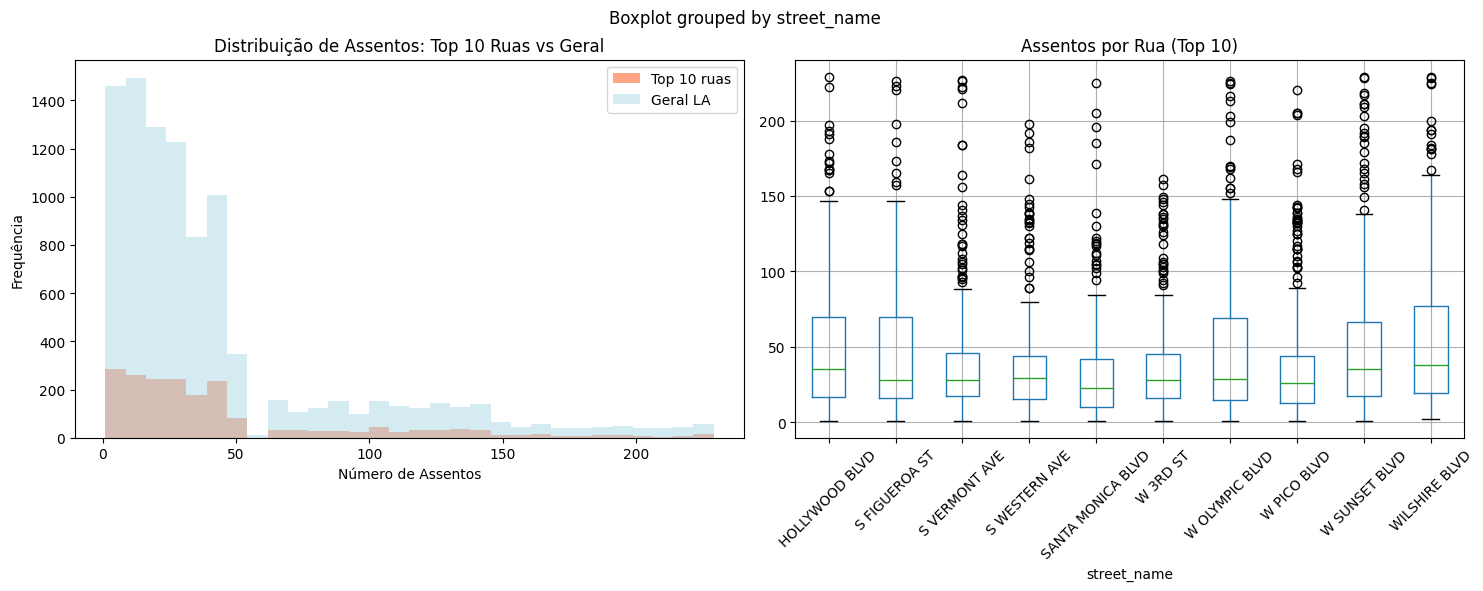

In [43]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.hist(estabelecimentos_top_ruas['number'], bins=30, alpha=0.7, color='coral', label='Top 10 ruas')
plt.hist(df['number'], bins=30, alpha=0.5, color='lightblue', label='Geral LA')
plt.title('Distribuição de Assentos: Top 10 Ruas vs Geral')
plt.xlabel('Número de Assentos')
plt.ylabel('Frequência')
plt.legend()

plt.subplot(2, 2, 2)
estabelecimentos_top_ruas.boxplot(column='number', by='street_name', ax=plt.gca())
plt.title('Assentos por Rua (Top 10)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

As manipulações solicitadas relativas ao endereço e análises correspondentes foram realizadas! Gráficos e conclusão estão presentes conforme solicitado.
</div>


Ruas com maior concentração de restaurantes apresentam estabelecimentos ligeiramente maiores e mais variados em tamanho, com predominância de espaços de porte médio e presença de unidades de grande capacidade. Isso ocorre devido ao alto fluxo de pessoas, maior concorrência e custos elevados, que incentivam maior capacidade e rentabilidade dos estabelecimentos.

Conclusão

A estratégia proposta posiciona a cafeteria de forma competitiva ao combinar localização privilegiada, dimensão operacional eficiente e um forte fator de diferenciação. Ao escolher ruas de alto fluxo e evitar áreas com baixa densidade comercial, maximiza-se o potencial de clientes.

O tamanho otimizado do espaço garante equilíbrio entre conforto e rentabilidade, enquanto a introdução de garçons robôs reforça um posicionamento inovador e memorável. Em vez de competir apenas por preço, o foco na experiência do cliente cria uma vantagem sustentável e difícil de replicar.

No conjunto, esta abordagem permite construir uma marca moderna, eficiente e centrada na experiência, com maior capacidade de atração e fidelização de clientes.

Apresentação para Investidores:

Link para a apresentação: 
https://drive.google.com/file/d/14_kwExIaka83qwaC5y4BO8EOjseJRu-6/view?usp=sharing

<div class="alert alert-danger">
<strong>Comentário do revisor v1</strong>

A conclusão está presente, no entanto a apresentação aponta para um link local. Poderia disponibilizá-la no google drive público?
</div>



<div class="alert alert-success">
<strong>Comentário do revisor v2</strong>

Obrigado pelo ajuste!
</div>
